# Unsupervised Clustering of Synthetic ALMA Protoplanetary Disk Images
## GSoC EXXA General Test 2026 — ML4Sci

This notebook builds a **unsupervised clustering pipeline** for the EXXA general test.

### What this notebook does
1. Loads the `.fits` cubes and keeps **layer 0** only.
2. Preprocesses each image with log scaling.
3. Estimates disk geometry, then **deprojects** the disk to reduce inclination/view-angle effects.
4. Extracts a small set of **planet-focused handcrafted features**.
5. Standardizes the features and runs **KMeans**.



## Colab setup

Install the required packages, download the zipped dataset from Google Drive, and extract it before running the rest of the notebook.


In [1]:
# Colab setup: install missing packages and download the zipped dataset
%pip install -q gdown astropy joblib

import os
import glob
import zipfile
import shutil
import gdown

DATA_ZIP_URL = "https://drive.google.com/file/d/1UTbvkSSIulT_42eyrF4z43BiKdlRheEE/view?usp=drive_link"
ZIP_PATH = "./exxa_data.zip"
EXTRACT_ROOT = "."
EXPECTED_DATA_DIR = "./data"

def count_fits_files(folder):
    return len(glob.glob(os.path.join(folder, "*.fits")))

if count_fits_files(EXPECTED_DATA_DIR) == 0:
    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)

    print("Downloading zipped dataset...")
    gdown.download(DATA_ZIP_URL, ZIP_PATH, quiet=False, fuzzy=True)

    if os.path.exists(EXPECTED_DATA_DIR):
        shutil.rmtree(EXPECTED_DATA_DIR)

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_ROOT)

print("Data directory:", os.path.abspath(EXPECTED_DATA_DIR))
print("Number of FITS files found:", count_fits_files(EXPECTED_DATA_DIR))


Downloading...
From (original): https://drive.google.com/uc?id=1UTbvkSSIulT_42eyrF4z43BiKdlRheEE
From (redirected): https://drive.google.com/uc?id=1UTbvkSSIulT_42eyrF4z43BiKdlRheEE&confirm=t&uuid=65c3721e-02a8-4524-a7cc-0ab5f7b5f4e0
To: /content/exxa_data.zip
100%|██████████| 634M/634M [00:07<00:00, 80.0MB/s]


Extracting dataset...
Data directory: /content/data
Number of FITS files found: 150


## 1. Imports and configuration

In [2]:
import os
import glob
import warnings
import joblib

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import simple_norm
from scipy.ndimage import map_coordinates, gaussian_filter1d
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_DIR = "./data"
LAYER_IDX = 0
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FEATURE_ORDER = [
    "fourier_m1_ratio",
    "fourier_m2_ratio",
    "rotational_asymmetry",
    "num_strong_gaps",
    "strongest_gap_prominence",
    "num_planets",
]

CONFIG = {
    "data_dir": DATA_DIR,
    "layer_idx": LAYER_IDX,
    "preprocess": True,
    "center_mask_frac": 0.03,
    "threshold_percentile": 70,
    "fourier_r_min": 5,
    "inner_cutoff": 0.20,
    "outer_cutoff": 1.00,
    "gap_smooth_sigma": 2.0,
    "gap_prominence": 0.08,
    "gap_min_distance": 8,
    "planet_smooth_sigma": 2.0,
    "planet_min_distance": 8,
    "planet_min_prominence": 0.03,
    "kmeans_k": 4,
}

CONFIG

{'data_dir': './data',
 'layer_idx': 0,
 'preprocess': True,
 'center_mask_frac': 0.03,
 'threshold_percentile': 70,
 'fourier_r_min': 5,
 'inner_cutoff': 0.2,
 'outer_cutoff': 1.0,
 'gap_smooth_sigma': 2.0,
 'gap_prominence': 0.08,
 'gap_min_distance': 8,
 'planet_smooth_sigma': 2.0,
 'planet_min_distance': 8,
 'planet_min_prominence': 0.03,
 'kmeans_k': 4}

## 2. Data loading and preprocessing

We load the FITS cube, keep only **index 0**, replace NaNs/Infs, and apply a **log stretch**.



In [3]:
def load_fits_image(path, layer_idx=0):
    with fits.open(path) as hdul:
        arr = hdul[0].data

    arr = np.asarray(arr).squeeze()

    if arr.ndim == 3:
        image = arr[layer_idx]
    elif arr.ndim == 2:
        image = arr
    else:
        raise ValueError(f"Unexpected FITS shape {arr.shape} for {path}")

    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return image


def load_dataset(data_dir, layer_idx=0):
    fits_paths = sorted(glob.glob(os.path.join(data_dir, "*.fits")))
    if len(fits_paths) == 0:
        raise FileNotFoundError(f"No FITS files found in {data_dir}")

    images, names = [], []
    for path in fits_paths:
        images.append(load_fits_image(path, layer_idx=layer_idx))
        names.append(os.path.basename(path))

    return np.array(images, dtype=np.float32), names


def log_scale_image(image):
    norm = simple_norm(image, stretch="log")
    scaled = np.asarray(norm(image), dtype=np.float32)
    return np.clip(scaled, 0.0, 1.0)


def preprocess_image(image):
    image = np.asarray(image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    return log_scale_image(image).astype(np.float32)

## 3. Geometry normalization: ellipse fitting and deprojection

A major failure mode here is clustering by **viewing angle** instead of by physically interesting structure.  
To reduce that risk, the pipeline:
- fits an ellipse to the bright disk region,
- estimates axis ratio and orientation,
- then deprojects the disk into a more face-on representation.

In [4]:
def fit_disk_ellipse_contour(image, center_mask_frac=0.03, threshold_percentile=85):
    h, w = image.shape

    img = np.asarray(image, dtype=np.float32)
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    img_min, img_max = img.min(), img.max()
    if img_max - img_min < 1e-8:
        return {"cx": (w - 1) / 2.0, "cy": (h - 1) / 2.0, "axis_ratio": 1.0, "theta": 0.0}

    img_8u = ((img - img_min) / (img_max - img_min) * 255.0).astype(np.uint8)
    work = img_8u.copy()

    center_mask_radius = max(1, int(center_mask_frac * min(h, w)))
    cv2.circle(work, (w // 2, h // 2), center_mask_radius, 0, -1)

    thresh_val = np.percentile(work, threshold_percentile)
    _, binary = cv2.threshold(work, thresh_val, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return {"cx": (w - 1) / 2.0, "cy": (h - 1) / 2.0, "axis_ratio": 1.0, "theta": 0.0}

    largest_contour = max(contours, key=cv2.contourArea)
    if len(largest_contour) < 5:
        return {"cx": (w - 1) / 2.0, "cy": (h - 1) / 2.0, "axis_ratio": 1.0, "theta": 0.0}

    (xc, yc), (d1, d2), angle_deg = cv2.fitEllipse(largest_contour)
    major_axis = max(d1, d2)
    minor_axis = min(d1, d2)
    axis_ratio = float(minor_axis / (major_axis + 1e-8))
    theta_deg = angle_deg if d1 >= d2 else angle_deg + 90.0

    return {
        "cx": float(xc),
        "cy": float(yc),
        "axis_ratio": float(np.clip(axis_ratio, 1e-3, 1.0)),
        "theta": float(np.deg2rad(theta_deg)),
    }


def inverse_warp_deproject(image, ellipse_params, output_shape=None, order=1):
    if output_shape is None:
        output_shape = image.shape

    h_out, w_out = output_shape
    cx = ellipse_params["cx"]
    cy = ellipse_params["cy"]
    q = max(float(ellipse_params["axis_ratio"]), 1e-3)
    theta = float(ellipse_params["theta"])

    y_out, x_out = np.indices((h_out, w_out))
    cx_out = (w_out - 1) / 2.0
    cy_out = (h_out - 1) / 2.0

    u = x_out - cx_out
    v = y_out - cy_out

    x_prime = u
    y_prime = v * q

    c = np.cos(theta)
    s = np.sin(theta)
    dx = x_prime * c - y_prime * s
    dy = x_prime * s + y_prime * c

    x_in = cx + dx
    y_in = cy + dy

    return map_coordinates(image, [y_in, x_in], order=order, mode="constant", cval=0.0).astype(np.float32)


def get_valid_mask(image_shape, ellipse_params):
    ones = np.ones(image_shape, dtype=np.float32)
    valid = inverse_warp_deproject(ones, ellipse_params, output_shape=image_shape, order=0)
    return valid > 0.5

## 4. Radial profiles and residual model

The disk is mostly radially structured, so we first estimate a **radial mean model** and subtract it.

This produces a **residual map** that highlights non-axisymmetric structure such as:
- localized bright features,
- asymmetries,
- and signatures that may correlate with planets.

In [5]:
def compute_radius_map(shape, center=None):
    h, w = shape
    if center is None:
        center = ((w - 1) / 2.0, (h - 1) / 2.0)
    cx, cy = center
    y, x = np.indices((h, w))
    return np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(np.float32)


def compute_theta_map(shape, center=None):
    h, w = shape
    if center is None:
        center = ((w - 1) / 2.0, (h - 1) / 2.0)
    cx, cy = center
    y, x = np.indices((h, w))
    return np.arctan2(y - cy, x - cx).astype(np.float32)


def radial_profile_stats(image, valid_mask=None, center=None):
    img = np.asarray(image, dtype=np.float32)
    h, w = img.shape
    if center is None:
        center = ((w - 1) / 2.0, (h - 1) / 2.0)

    radius_map = compute_radius_map(img.shape, center=center)
    r_int = np.floor(radius_map).astype(np.int32)

    valid_mask = np.ones_like(img, dtype=bool) if valid_mask is None else valid_mask.astype(bool)
    values = img[valid_mask]
    rvals = r_int[valid_mask]

    if rvals.size == 0:
        return (
            np.array([], dtype=np.float32),
            np.array([], dtype=np.float32),
            np.array([], dtype=np.float32),
            np.array([], dtype=np.int32),
            radius_map,
        )

    max_r = int(rvals.max())
    counts = np.bincount(rvals, minlength=max_r + 1).astype(np.int32)
    sums = np.bincount(rvals, weights=values, minlength=max_r + 1).astype(np.float64)
    sqs = np.bincount(rvals, weights=values**2, minlength=max_r + 1).astype(np.float64)

    radial_mean = np.zeros_like(sums, dtype=np.float32)
    radial_std = np.zeros_like(sums, dtype=np.float32)

    nz = counts > 0
    radial_mean[nz] = (sums[nz] / counts[nz]).astype(np.float32)

    var = np.zeros_like(sums, dtype=np.float64)
    var[nz] = sqs[nz] / counts[nz] - (sums[nz] / counts[nz])**2
    radial_std[nz] = np.sqrt(np.clip(var[nz], 0.0, None)).astype(np.float32)

    radii = np.arange(len(radial_mean), dtype=np.float32)
    return radii, radial_mean, radial_std, counts, radius_map


def radial_profile_max(image, valid_mask=None, center=None):
    img = np.asarray(image, dtype=np.float32)
    h, w = img.shape
    if center is None:
        center = ((w - 1) / 2.0, (h - 1) / 2.0)

    radius_map = compute_radius_map(img.shape, center=center)
    r_int = np.floor(radius_map).astype(np.int32)
    valid_mask = np.ones_like(img, dtype=bool) if valid_mask is None else valid_mask.astype(bool)

    values = img[valid_mask]
    rvals = r_int[valid_mask]
    if rvals.size == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32), radius_map

    max_r = int(rvals.max())
    max_profile = np.full(max_r + 1, -np.inf, dtype=np.float32)
    for r, v in zip(rvals, values):
        if v > max_profile[r]:
            max_profile[r] = v

    max_profile[~np.isfinite(max_profile)] = 0.0
    return np.arange(len(max_profile), dtype=np.float32), max_profile, radius_map


def flux_radii_from_profile(radii, radial_mean, counts):
    flux_per_ring = radial_mean * counts
    total_flux = np.sum(flux_per_ring)
    if total_flux <= 1e-8:
        return 0.0, 1.0

    cdf = np.cumsum(flux_per_ring) / (total_flux + 1e-8)
    r50_idx = np.searchsorted(cdf, 0.50)
    r90_idx = np.searchsorted(cdf, 0.90)

    r50 = float(radii[min(r50_idx, len(radii) - 1)])
    r90 = max(float(radii[min(r90_idx, len(radii) - 1)]), 1.0)
    return r50, r90


def build_radial_model(radial_mean, radius_map):
    r0 = np.floor(radius_map).astype(np.int32)
    r0 = np.clip(r0, 0, len(radial_mean) - 1)
    return radial_mean[r0].astype(np.float32)

## 5. Final feature set

Only the final features actually used for clustering are kept.

### Feature meanings
- **`fourier_m1_ratio`**: strength of the first azimuthal mode in the residual map. It captures one-sided asymmetry.
- **`fourier_m2_ratio`**: strength of the second azimuthal mode in the residual map. It captures two-lobed / two-sided structure.
- **`rotational_asymmetry`**: difference between the residual map and its 180° rotation. Larger values mean the disk is less symmetric.
- **`num_strong_gaps`**: number of strong minima found in the smoothed radial brightness profile.
- **`strongest_gap_prominence`**: depth/importance of the strongest detected gap in the radial profile.
- **`num_planets`**: number of strong residual peaks found in the radial max profile after smoothing.

These are meant to emphasize **planet-related morphology** rather than simple viewing angle.

In [6]:
def compute_rotational_asymmetry(residual, valid_mask):
    valid = valid_mask.astype(bool)
    if valid.sum() == 0:
        return 0.0

    rotated = np.rot90(np.rot90(residual))
    rotated_valid = np.rot90(np.rot90(valid))
    common = valid & rotated_valid
    if common.sum() == 0:
        return 0.0

    num = np.mean(np.abs(residual[common] - rotated[common]))
    den = np.mean(np.abs(residual[common])) + 1e-8
    return float(num / den)


def compute_fourier_ratios(image, theta_map, radius_map, valid_mask, r_min=5, r_max=None, modes=(1, 2, 3)):
    valid = valid_mask.astype(bool)
    if not np.any(valid):
        return {f"fourier_m{m}_ratio": 0.0 for m in modes}

    if r_max is None:
        r_max = float(np.max(radius_map[valid]))

    ring_mask = valid & (radius_map >= r_min) & (radius_map <= r_max)
    if np.sum(ring_mask) == 0:
        return {f"fourier_m{m}_ratio": 0.0 for m in modes}

    vals = image[ring_mask].astype(np.float32)
    th = theta_map[ring_mask].astype(np.float32)
    a0 = np.mean(np.abs(vals)) + 1e-8

    out = {}
    for m in modes:
        coeff = np.mean(vals * np.exp(-1j * m * th))
        out[f"fourier_m{m}_ratio"] = float(np.abs(coeff) / a0)
    return out


def detect_strong_gaps_from_profile(radial_mean_norm, radii_norm, smooth_sigma=3.0, gap_prominence=0.10, min_gap_distance=12, min_gap_width=4):
    if len(radial_mean_norm) == 0:
        return {
            "num_strong_gaps": 0,
            "strongest_gap_radius": 0.0,
            "strongest_gap_prominence": 0.0,
            "smoothed_profile": np.array([], dtype=np.float32),
            "gap_indices": np.array([], dtype=np.int32),
            "gap_prominences": np.array([], dtype=np.float32),
        }

    prof = gaussian_filter1d(radial_mean_norm.astype(np.float32), sigma=smooth_sigma)
    gap_idx, gap_props = find_peaks(-prof, prominence=gap_prominence, distance=min_gap_distance, width=min_gap_width)
    gap_prom = gap_props.get("prominences", np.array([], dtype=np.float32))

    if len(gap_idx) > 0:
        strongest_idx = int(np.argmax(gap_prom))
        strongest_gap_radius = float(radii_norm[gap_idx[strongest_idx]])
        strongest_gap_prominence = float(gap_prom[strongest_idx])
    else:
        strongest_gap_radius = 0.0
        strongest_gap_prominence = 0.0

    return {
        "num_strong_gaps": int(len(gap_idx)),
        "strongest_gap_radius": strongest_gap_radius,
        "strongest_gap_prominence": strongest_gap_prominence,
        "smoothed_profile": prof,
        "gap_indices": gap_idx.astype(np.int32),
        "gap_prominences": np.asarray(gap_prom, dtype=np.float32),
    }


def detect_planets_from_residual_profile(residual_max_norm, residual_radii_norm, smooth_sigma=2.0, min_peak_distance=8, min_peak_prominence=0.03, weak_factor=2.5, strong_factor=6.0):
    if len(residual_max_norm) == 0:
        return {
            "num_planets": 0,
            "mean_profile": 0.0,
            "smoothed_profile": np.array([], dtype=np.float32),
            "peak_indices": np.array([], dtype=np.int32),
            "peak_heights": np.array([], dtype=np.float32),
            "peak_radii": np.array([], dtype=np.float32),
            "weak_mask": np.array([], dtype=bool),
            "strong_mask": np.array([], dtype=bool),
        }

    prof = gaussian_filter1d(residual_max_norm.astype(np.float32), sigma=smooth_sigma)
    mean_prof = float(np.mean(prof) + 1e-8)

    peak_idx, _ = find_peaks(prof, prominence=min_peak_prominence, distance=min_peak_distance)
    peak_heights = prof[peak_idx] if len(peak_idx) > 0 else np.array([], dtype=np.float32)
    peak_radii = residual_radii_norm[peak_idx] if len(peak_idx) > 0 else np.array([], dtype=np.float32)

    weak_mask = (peak_heights > (weak_factor * mean_prof)) & (peak_heights < (strong_factor * mean_prof))
    strong_mask = peak_heights >= (strong_factor * mean_prof)
    num_planets = int(np.sum(weak_mask)) + int(np.sum(strong_mask))

    return {
        "num_planets": num_planets,
        "mean_profile": mean_prof,
        "smoothed_profile": prof,
        "peak_indices": peak_idx.astype(np.int32),
        "peak_heights": np.asarray(peak_heights, dtype=np.float32),
        "peak_radii": np.asarray(peak_radii, dtype=np.float32),
        "weak_mask": weak_mask,
        "strong_mask": strong_mask,
    }


def extract_disk_features_focused(
    image,
    center_mask_frac=0.03,
    threshold_percentile=70,
    fourier_r_min=5,
    inner_cutoff=0.2,
    outer_cutoff=1.00,
    gap_smooth_sigma=2.0,
    gap_prominence=0.06,
    gap_min_distance=8,
    planet_smooth_sigma=1,
    planet_min_distance=8,
    planet_min_prominence=0.03,
):
    img = np.asarray(image, dtype=np.float32)
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    ellipse_params = fit_disk_ellipse_contour(
        img,
        center_mask_frac=center_mask_frac,
        threshold_percentile=threshold_percentile,
    )

    deproj = inverse_warp_deproject(img, ellipse_params, output_shape=img.shape, order=1)
    valid_mask = get_valid_mask(img.shape, ellipse_params)

    h, w = deproj.shape
    center = ((w - 1) / 2.0, (h - 1) / 2.0)

    radii, radial_mean, radial_std, counts, radius_map = radial_profile_stats(deproj, valid_mask=valid_mask, center=center)
    theta_map = compute_theta_map(deproj.shape, center=center)

    r50, r90 = flux_radii_from_profile(radii, radial_mean, counts)
    eps = 1e-8

    radii_norm = radii / (r90 + eps)
    radial_mean_norm = radial_mean / (np.max(radial_mean) + eps) if len(radial_mean) > 0 else radial_mean

    radial_model = build_radial_model(radial_mean, radius_map)
    residual = np.abs(deproj - radial_model) * valid_mask.astype(np.float32)

    residual_radii, residual_max, _ = radial_profile_max(residual, valid_mask=valid_mask, center=center)
    residual_radii_norm = residual_radii / (r90 + eps)
    residual_max_norm = residual_max / (np.max(residual_max) + eps) if len(residual_max) > 0 else residual_max

    clean_mask_radial = (radii_norm >= inner_cutoff) & (radii_norm <= outer_cutoff)
    clean_radii_norm = radii_norm[clean_mask_radial]
    clean_radial_mean = radial_mean_norm[clean_mask_radial]

    clean_mask_residual = (residual_radii_norm >= inner_cutoff) & (residual_radii_norm <= outer_cutoff)
    clean_residual_radii_norm = residual_radii_norm[clean_mask_residual]
    clean_residual_max_norm = residual_max_norm[clean_mask_residual]

    gap_info = detect_strong_gaps_from_profile(
        radial_mean_norm=clean_radial_mean,
        radii_norm=clean_radii_norm,
        smooth_sigma=gap_smooth_sigma,
        gap_prominence=gap_prominence,
        min_gap_distance=gap_min_distance,
    )

    planet_info = detect_planets_from_residual_profile(
        residual_max_norm=clean_residual_max_norm,
        residual_radii_norm=clean_residual_radii_norm,
        smooth_sigma=planet_smooth_sigma,
        min_peak_distance=planet_min_distance,
        min_peak_prominence=planet_min_prominence,
        weak_factor=2.5,
        strong_factor=6.0,
    )

    rotational_asymmetry = compute_rotational_asymmetry(residual, valid_mask)

    modes =  (1, 2)
    fourier = compute_fourier_ratios(
        image=residual,
        theta_map=theta_map,
        radius_map=radius_map,
        valid_mask=valid_mask,
        r_min=fourier_r_min,
        r_max=r90,
        modes=modes,
    )

    scalar_features = {
        "fourier_m1_ratio": float(fourier["fourier_m1_ratio"]),
        "fourier_m2_ratio": float(fourier["fourier_m2_ratio"]),
        "rotational_asymmetry": float(rotational_asymmetry),
        "num_strong_gaps": float(gap_info["num_strong_gaps"]),
        "strongest_gap_prominence": float(gap_info["strongest_gap_prominence"]),
        "num_planets": float(planet_info["num_planets"]),
    }

    aux = {
        "deproj": deproj,
        "valid_mask": valid_mask,
        "residual": residual,
        "ellipse_params": ellipse_params,
        "r50": r50,
        "r90": r90,
        "radii_norm_raw": clean_radii_norm,
        "radial_mean_norm_raw": clean_radial_mean,
        "residual_radii_norm_raw": clean_residual_radii_norm,
        "residual_max_norm_raw": clean_residual_max_norm,
        "gap_info": gap_info,
        "planet_info": planet_info,
        "all_scalars": scalar_features.copy(),
    }

    return {"scalar_features": scalar_features, "aux": aux}


def feature_dict_to_vector(feat_dict, feature_order=FEATURE_ORDER):
    return np.array([float(feat_dict.get(k, 0.0)) for k in feature_order], dtype=np.float32)

## 6. Helper visualizations for one sample

In [7]:
def visualize_gap_detection(result, title=None):
    aux = result["aux"]
    x = aux["radii_norm_raw"]
    y = aux["radial_mean_norm_raw"]
    gap_info = aux["gap_info"]

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="radial mean", alpha=0.6)
    plt.plot(x, gap_info["smoothed_profile"], label="smoothed", linewidth=2)

    if len(gap_info["gap_indices"]) > 0:
        gi = gap_info["gap_indices"]
        plt.scatter(x[gi], gap_info["smoothed_profile"][gi], marker="v", s=70, label="strong gaps")

    plt.xlabel("Normalized radius")
    plt.ylabel("Normalized radial mean")
    plt.title(title if title is not None else "Strong gap detection")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def visualize_planet_detection(result, title=None):
    aux = result["aux"]
    x = aux["residual_radii_norm_raw"]
    y = aux["residual_max_norm_raw"]
    planet_info = aux["planet_info"]
    prof = planet_info["smoothed_profile"]

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="residual radial max", alpha=0.6)
    plt.plot(x, prof, label="smoothed", linewidth=2)

    mean_prof = planet_info["mean_profile"]
    plt.axhline(2.5 * mean_prof, linestyle="--", label="2.5 × mean")
    plt.axhline(6.0 * mean_prof, linestyle="--", label="6 × mean")

    if len(planet_info["peak_indices"]) > 0:
        pi = planet_info["peak_indices"]
        weak_idx = pi[planet_info["weak_mask"]]
        strong_idx = pi[planet_info["strong_mask"]]

        if len(weak_idx) > 0:
            plt.scatter(x[weak_idx], prof[weak_idx], marker="o", s=70, label="weak planets")
        if len(strong_idx) > 0:
            plt.scatter(x[strong_idx], prof[strong_idx], marker="*", s=120, label="strong planets")

    plt.xlabel("Normalized radius")
    plt.ylabel("Normalized residual max")
    plt.title(title if title is not None else "Planet-candidate detection")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def visualize_feature_maps(result, image=None, title_prefix=""):
    aux = result["aux"]
    deproj = aux["deproj"]
    residual = aux["residual"]
    valid_mask = aux["valid_mask"]

    fig, axes = plt.subplots(1, 4 if image is not None else 3, figsize=(18, 4))

    idx = 0
    if image is not None:
        axes[idx].imshow(image, origin="lower", cmap="inferno")
        axes[idx].set_title(f"{title_prefix}Original")
        axes[idx].axis("off")
        idx += 1

    axes[idx].imshow(deproj, origin="lower", cmap="inferno")
    axes[idx].set_title(f"{title_prefix}Deprojected")
    axes[idx].axis("off")
    idx += 1

    axes[idx].imshow(residual, origin="lower", cmap="inferno")
    axes[idx].set_title(f"{title_prefix}Residual")
    axes[idx].axis("off")
    idx += 1

    axes[idx].imshow(valid_mask, origin="lower", cmap="gray")
    axes[idx].set_title(f"{title_prefix}Valid mask")
    axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

## 7. Dataset-wide feature extraction and clustering

### Clustering choice
Per your request, the notebook uses:
- **standardization**
- **no PCA inside clustering**
- **KMeans with `k=4` only**

PCA is used later only for **2D visualization**.

In [8]:
def extract_features_for_dataset(
    data_dir="../data",
    layer_idx=0,
    preprocess=True,
    center_mask_frac=0.03,
    threshold_percentile=70,
    fourier_r_min=5,
    inner_cutoff=0.30,
    outer_cutoff=1.00,
    gap_smooth_sigma=2.0,
    gap_prominence=0.06,
    gap_min_distance=8,
    planet_smooth_sigma=2.0,
    planet_min_distance=8,
    planet_min_prominence=0.03,
):
    images, names = load_dataset(data_dir, layer_idx=layer_idx)

    all_results = []
    all_vectors = []
    processed_images = []

    for i, img in enumerate(images):
        work_img = preprocess_image(img) if preprocess else img
        processed_images.append(work_img)

        res = extract_disk_features_focused(
            work_img,
            center_mask_frac=center_mask_frac,
            threshold_percentile=threshold_percentile,
            fourier_r_min=fourier_r_min,
            inner_cutoff=inner_cutoff,
            outer_cutoff=outer_cutoff,
            gap_smooth_sigma=gap_smooth_sigma,
            gap_prominence=gap_prominence,
            gap_min_distance=gap_min_distance,
            planet_smooth_sigma=planet_smooth_sigma,
            planet_min_distance=planet_min_distance,
            planet_min_prominence=planet_min_prominence,
        )

        all_vectors.append(feature_dict_to_vector(res["scalar_features"], FEATURE_ORDER))
        all_results.append(res)

        if (i + 1) % 20 == 0 or (i + 1) == len(images):
            print(f"Processed {i + 1}/{len(images)} images")

    return {
        "images_raw": images,
        "images_processed": np.array(processed_images, dtype=np.float32),
        "names": names,
        "results": all_results,
        "X_raw": np.vstack(all_vectors).astype(np.float32),
    }


def prepare_features(X_raw):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)


    feature_weights = {
        "num_planets": 2.0,
        "num_strong_gaps": 3.0,
        "strongest_gap_prominence": 3.0,
        "fourier_m1_ratio": 1.5,
        "fourier_m2_ratio": 1.25,
        "rotational_asymmetry": 1.25,
    }

    X_weighted = X_scaled.copy()
    for i, name in enumerate(FEATURE_ORDER):
        X_weighted[:, i] *= feature_weights.get(name, 1.0)

    return {
        "X_scaled": X_scaled,
        "X_final": X_weighted,
        "scaler": scaler,
        "feature_weights": feature_weights,
    }


def run_kmeans_k4(X, random_state=SEED):
    model = KMeans(n_clusters=4, random_state=random_state, n_init="auto")
    labels = model.fit_predict(X)
    return model, labels


def clustering_score(X, labels):
    unique = np.unique(labels)
    if len(unique) < 2:
        return np.nan
    return silhouette_score(X, labels)


def summarize_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return {int(k): int(v) for k, v in zip(unique, counts)}


def build_feature_table(X_raw, names, feature_order=FEATURE_ORDER):
    df = pd.DataFrame(X_raw, columns=feature_order)
    df.insert(0, "name", names)
    return df


def build_cluster_table(X_raw, names, labels, feature_order=FEATURE_ORDER):
    df = build_feature_table(X_raw, names, feature_order=feature_order)
    df["cluster"] = labels
    return df


def cluster_feature_means(df, feature_order=FEATURE_ORDER):
    return df.groupby("cluster")[list(feature_order)].mean().sort_index()

## 8. Cluster visualizations

In [9]:
def make_pca_2d_embedding(X):
    return PCA(n_components=2, random_state=SEED).fit_transform(X)


def plot_clusters_2d(embedding, labels, title="Clusters"):
    plt.figure(figsize=(7, 6))
    for lab in np.unique(labels):
        mask = labels == lab
        plt.scatter(embedding[mask, 0], embedding[mask, 1], s=35, alpha=0.8, label=f"cluster {lab}")

    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def show_cluster_examples(images, names, labels, cluster_id, n_show=8):
    idxs = np.where(labels == cluster_id)[0]
    if len(idxs) == 0:
        print(f"No samples in cluster {cluster_id}")
        return

    idxs = idxs[:n_show]
    cols = min(4, len(idxs))
    rows = int(np.ceil(len(idxs) / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))
    for j, idx in enumerate(idxs, 1):
        plt.subplot(rows, cols, j)
        plt.imshow(images[idx], origin="lower", cmap="inferno")
        plt.title(f"{names[idx]}\ncluster {cluster_id}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_examples_for_all_clusters(images, names, labels, n_show=8):
    for cid in np.unique(labels):
        print(f"Cluster {cid}")
        show_cluster_examples(images, names, labels, cid, n_show=n_show)


def show_cluster_representatives(images, names, labels, features_scaled, kmeans_model, n_show=3):

    cluster_ids = np.unique(labels)

    for cid in cluster_ids:
        idxs = np.where(labels == cid)[0]
        if len(idxs) == 0:
            print(f"No samples in cluster {cid}")
            continue

        center = kmeans_model.cluster_centers_[cid]
        dists = np.linalg.norm(features_scaled[idxs] - center, axis=1)
        order = np.argsort(dists)
        chosen = idxs[order[:min(n_show, len(order))]]

        cols = len(chosen)
        plt.figure(figsize=(4 * cols, 4))
        for j, idx in enumerate(chosen, 1):
            plt.subplot(1, cols, j)
            plt.imshow(images[idx], origin="lower", cmap="inferno")
            plt.title(f"{names[idx]}cluster {cid}")
            plt.axis("off")

        plt.suptitle(f"Cluster {cid}: {len(chosen)} most representative images", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()



def show_cluster_mean_images(images, labels, cmap="inferno"):
    cluster_ids = np.unique(labels)
    n = len(cluster_ids)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, cid in zip(axes, cluster_ids):
        idxs = np.where(labels == cid)[0]
        mean_img = np.mean(images[idxs], axis=0)
        ax.imshow(mean_img, origin="lower", cmap=cmap)
        ax.set_title(f"Cluster {cid}\nMean image (n={len(idxs)})")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def save_images_by_cluster(
    images,
    names,
    labels,
    output_dir="clustered_images",
    cmap="inferno",
    dpi=150,
):
    os.makedirs(output_dir, exist_ok=True)

    for img, name, label in zip(images, names, labels):
        cluster_dir = os.path.join(output_dir, f"cluster_{label}")
        os.makedirs(cluster_dir, exist_ok=True)

        base_name = os.path.splitext(os.path.basename(str(name)))[0]
        save_path = os.path.join(cluster_dir, f"{base_name}.png")

        plt.figure(figsize=(5, 5))
        plt.imshow(img, cmap=cmap, origin="lower")
        plt.axis("off")
        plt.tight_layout(pad=0)
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0, dpi=dpi)
        plt.close()

## 9. Quick sanity check on one image

Preview file: planet100_00580_1250.fits
{'fourier_m1_ratio': 0.0457930751144886, 'fourier_m2_ratio': 0.10716412216424942, 'rotational_asymmetry': 0.8557690382003784, 'num_strong_gaps': 1.0, 'strongest_gap_prominence': 0.12695187330245972, 'num_planets': 2.0}


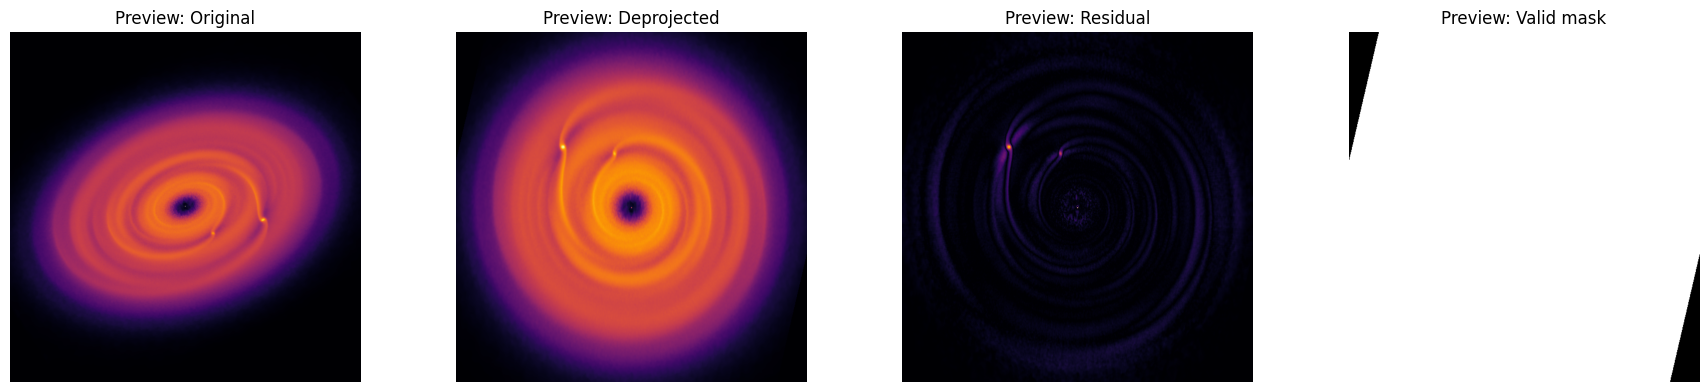

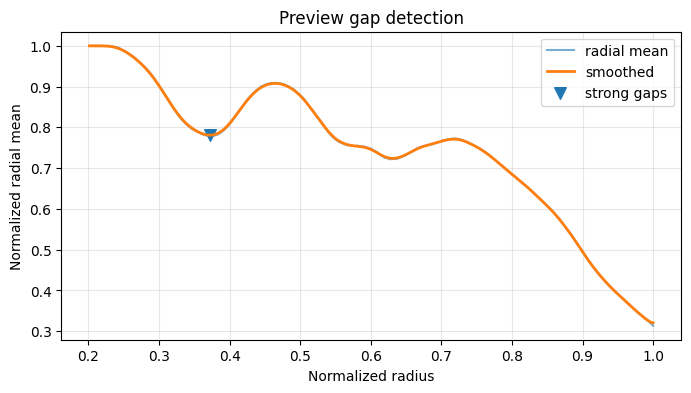

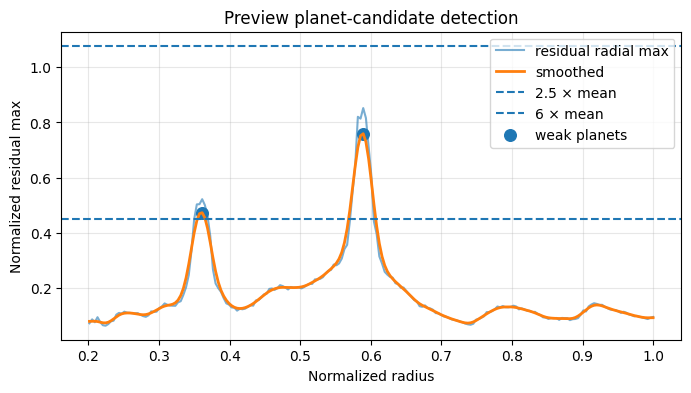

In [10]:
images_preview, names_preview = load_dataset(CONFIG["data_dir"], layer_idx=CONFIG["layer_idx"])
preview_img = preprocess_image(images_preview[1])

preview_result = extract_disk_features_focused(
    preview_img,
    center_mask_frac=CONFIG["center_mask_frac"],
    threshold_percentile=CONFIG["threshold_percentile"],
    fourier_r_min=CONFIG["fourier_r_min"],
    inner_cutoff=CONFIG["inner_cutoff"],
    outer_cutoff=CONFIG["outer_cutoff"],
    gap_smooth_sigma=CONFIG["gap_smooth_sigma"],
    gap_prominence=CONFIG["gap_prominence"],
    gap_min_distance=CONFIG["gap_min_distance"],
    planet_smooth_sigma=CONFIG["planet_smooth_sigma"],
    planet_min_distance=CONFIG["planet_min_distance"],
    planet_min_prominence=CONFIG["planet_min_prominence"],
)

print("Preview file:", names_preview[1])
print(preview_result["scalar_features"])
visualize_feature_maps(preview_result, image=preview_img, title_prefix="Preview: ")
visualize_gap_detection(preview_result, title="Preview gap detection")
visualize_planet_detection(preview_result, title="Preview planet-candidate detection")

## 10. Full pipeline run

In [11]:
dataset = extract_features_for_dataset(
    data_dir=CONFIG["data_dir"],
    layer_idx=CONFIG["layer_idx"],
    preprocess=CONFIG["preprocess"],
    center_mask_frac=CONFIG["center_mask_frac"],
    threshold_percentile=CONFIG["threshold_percentile"],
    fourier_r_min=CONFIG["fourier_r_min"],
    inner_cutoff=CONFIG["inner_cutoff"],
    outer_cutoff=CONFIG["outer_cutoff"],
    gap_smooth_sigma=CONFIG["gap_smooth_sigma"],
    gap_prominence=CONFIG["gap_prominence"],
    gap_min_distance=CONFIG["gap_min_distance"],
    planet_smooth_sigma=CONFIG["planet_smooth_sigma"],
    planet_min_distance=CONFIG["planet_min_distance"],
    planet_min_prominence=CONFIG["planet_min_prominence"],
)

X_raw = dataset["X_raw"]
results = dataset["results"]
images_processed = dataset["images_processed"]
images_raw = dataset["images_raw"]
names = dataset["names"]

print("Feature matrix shape:", X_raw.shape)
df_features = build_feature_table(X_raw, names)
df_features.head()

Processed 20/150 images
Processed 40/150 images
Processed 60/150 images
Processed 80/150 images
Processed 100/150 images
Processed 120/150 images
Processed 140/150 images
Processed 150/150 images
Feature matrix shape: (150, 6)


,name,fourier_m1_ratio,fourier_m2_ratio,rotational_asymmetry,num_strong_gaps,strongest_gap_prominence,num_planets
0,planet0_00226_1250.fits,0.103743,0.041264,0.711283,0.0,0.000000,1.0
1,planet100_00580_1250.fits,0.045793,0.107164,0.855769,1.0,0.126952,2.0
2,planet101_00972_1250.fits,0.075207,0.112429,0.869850,1.0,0.467813,1.0
3,planet101_00988_1250.fits,0.061148,0.062641,0.838724,1.0,0.482635,1.0
4,planet102_00142_1250.fits,0.027224,0.030332,0.705485,0.0,0.000000,0.0


In [12]:
prep = prepare_features(X_raw)
X_final = prep["X_final"]

kmeans_model, labels = run_kmeans_k4(X_final, random_state=SEED)
sil = clustering_score(X_final, labels)

print("Chosen clustering: KMeans with k=4")
print("Label counts:", summarize_labels(labels))

Chosen clustering: KMeans with k=4
Label counts: {0: 53, 1: 51, 2: 16, 3: 30}


## 11. PCA visualization of the clustering

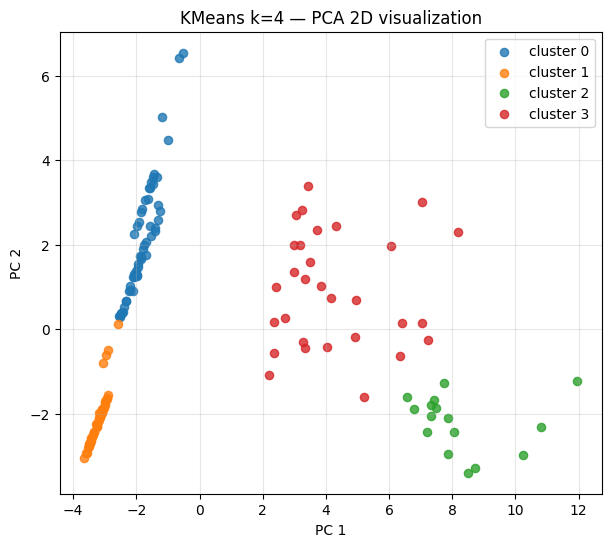

In [13]:
embedding_2d = make_pca_2d_embedding(X_final)
plot_clusters_2d(embedding_2d, labels, title="KMeans k=4 — PCA 2D visualization")

## 12. Cluster-level feature summary

In [14]:
df_clusters = build_cluster_table(X_raw, names, labels)
cluster_means_df = cluster_feature_means(df_clusters)
cluster_means_df

,fourier_m1_ratio,fourier_m2_ratio,rotational_asymmetry,num_strong_gaps,strongest_gap_prominence,num_planets
cluster,,,,,,
0,0.082032,0.075078,0.794806,0.000000,0.000000,1.396226
1,0.015794,0.013272,0.564023,0.000000,0.000000,0.078431
2,0.080219,0.089401,0.840992,1.312500,0.472926,0.937500
3,0.090473,0.103566,0.836853,1.233333,0.159068,1.366667


## 13. Cluster examples and representative images


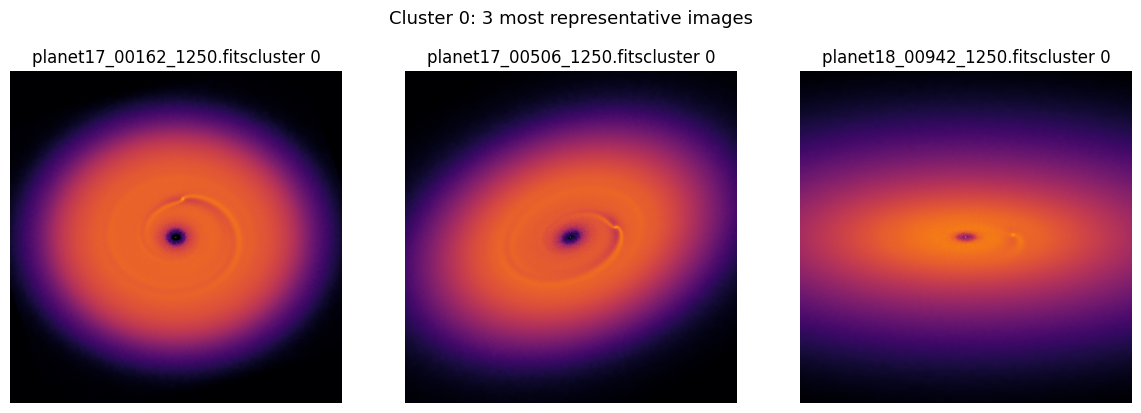

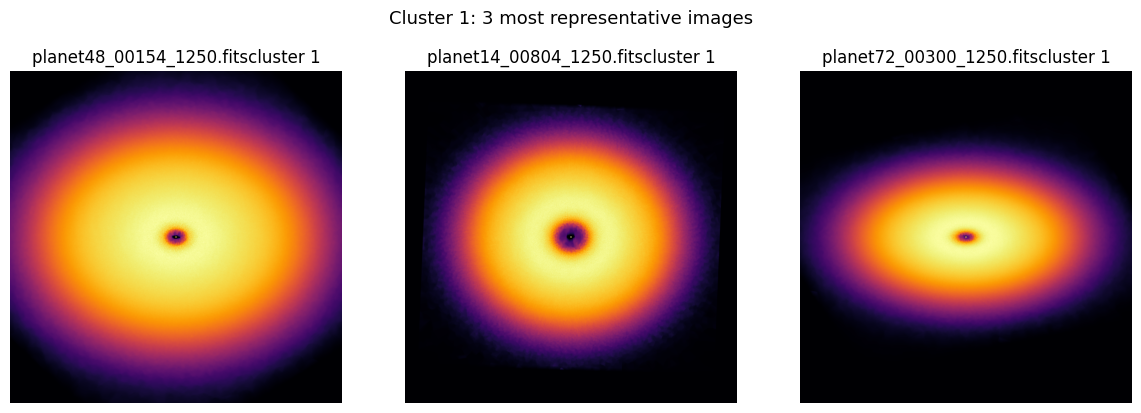

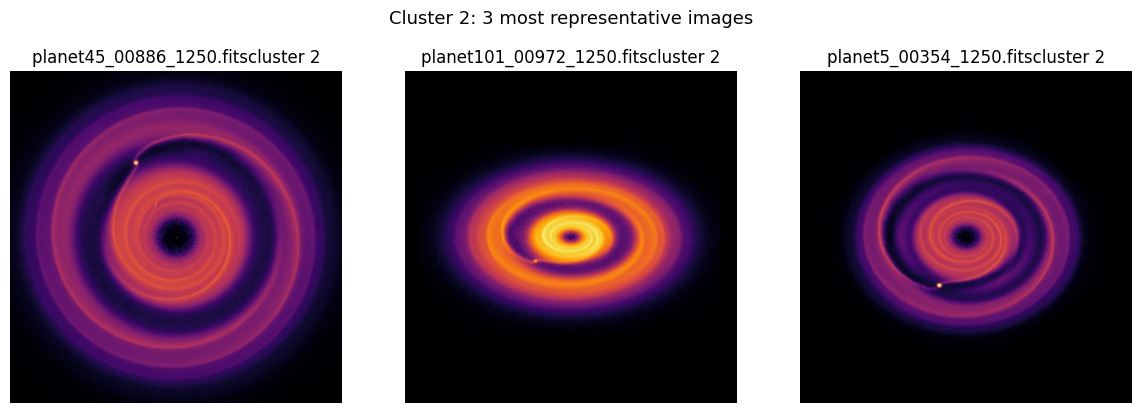

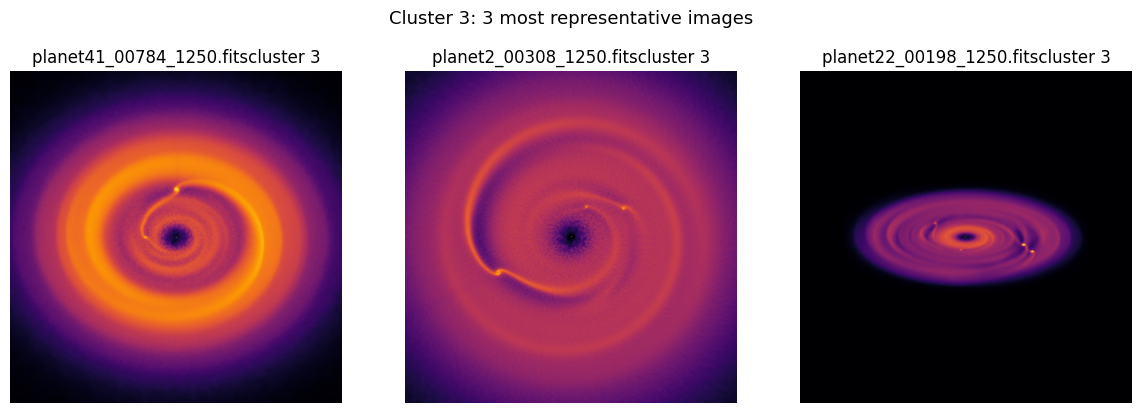

In [15]:
show_cluster_representatives(images_processed, names, labels, X_final, kmeans_model, n_show=3)



### Cluster interpretation used in this notebook
- **Cluster 0:** no or faint gaps, moderately symmetric, and has planets.
- **Cluster 1:** no gaps, symmetric, 0 or very faint planets.
- **Cluster 2:** very strong gaps, planets, not symmetric.
- **Cluster 3:** moderate gaps and spirals, planets, not symmetric.


## 14. Save images grouped by cluster

In [16]:
# save_images_by_cluster(
#     images=images_processed,
#     names=names,
#     labels=labels,
#     output_dir="clustered_images_k4",
#     cmap="inferno",
#     dpi=150,
# )

# print("Images saved by cluster in: clustered_images_k4/")

## 15. Save the fitted pipeline for withheld-data inference

In [17]:
pipeline_artifact = {
    "config": CONFIG,
    "feature_order": FEATURE_ORDER,
    "feature_weights": prep["feature_weights"],
    "scaler": prep["scaler"],
    "cluster_model": kmeans_model,
    "silhouette_score": sil,
}

artifact_path = os.path.join(OUTPUT_DIR, "exxa_disk_clustering_pipeline_k4.joblib")
joblib.dump(pipeline_artifact, artifact_path)
print("Saved pipeline artifact to:", artifact_path)

Saved pipeline artifact to: ./outputs/exxa_disk_clustering_pipeline_k4.joblib


In [18]:
def predict_clusters_for_directory(data_dir, pipeline_path, layer_idx=0):
    saved_pipeline = joblib.load(pipeline_path)
    cfg = saved_pipeline["config"]
    feature_order = saved_pipeline["feature_order"]
    feature_weights = saved_pipeline["feature_weights"]

    dataset = extract_features_for_dataset(
        data_dir=data_dir,
        layer_idx=layer_idx,
        preprocess=cfg["preprocess"],
        center_mask_frac=cfg["center_mask_frac"],
        threshold_percentile=cfg["threshold_percentile"],
        fourier_r_min=cfg["fourier_r_min"],
        inner_cutoff=cfg["inner_cutoff"],
        outer_cutoff=cfg["outer_cutoff"],
        gap_smooth_sigma=cfg["gap_smooth_sigma"],
        gap_prominence=cfg["gap_prominence"],
        gap_min_distance=cfg["gap_min_distance"],
        planet_smooth_sigma=cfg["planet_smooth_sigma"],
        planet_min_distance=cfg["planet_min_distance"],
        planet_min_prominence=cfg["planet_min_prominence"],
    )

    X_raw = dataset["X_raw"]

    # same scaling as training
    X_scaled = saved_pipeline["scaler"].transform(X_raw)

    # same feature weighting as training
    X_final = X_scaled.copy()
    for i, name in enumerate(feature_order):
        X_final[:, i] *= feature_weights.get(name, 1.0)

    cluster_model = saved_pipeline["cluster_model"]
    labels = cluster_model.predict(X_final)

    out = build_cluster_table(X_raw, dataset["names"], labels)
    return out, dataset, X_final, cluster_model

## 16. Reviewer cell for new / withheld data

This final cell is meant for evaluators. They only need to provide the folder containing `.fits` files and the saved pipeline artifact. The code then extracts features using the same configuration, predicts cluster IDs, attaches the cluster interpretation labels used in this notebook, and visualizes representative disks for each predicted cluster.


In [21]:
# ── Reviewer: set this to your withheld data folder ──────────────────────────
review_data_dir = "path/to/yourdata"
review_pipeline_path = os.path.join(OUTPUT_DIR, "exxa_disk_clustering_pipeline_k4.joblib")
# ─────────────────────────────────────────────────────────────────────────────

cluster_descriptions = {
    0: "no or faint gaps, moderately symmetric, and has planets",
    1: "no gaps, symmetric, 0 or very faint planets",
    2: "very strong gaps, planets, not symmetric",
    3: "moderate gaps and spirals, planets, not symmetric",
}

review_df, review_dataset, review_X_final, review_model = predict_clusters_for_directory(
    data_dir=review_data_dir,
    pipeline_path=review_pipeline_path,
    layer_idx=0,
)

review_labels = review_df["cluster"].values
review_df["cluster_description"] = review_df["cluster"].map(cluster_descriptions)

print("Predicted samples:", len(review_df))
print("\nCluster distribution:")
print(review_df["cluster"].value_counts())

display(review_df[["name", "cluster", "cluster_description"]])

# ── Visual inspection: most representative images per cluster ─────────────────
print("\nRepresentative disk images per predicted cluster:")
show_cluster_representatives(
    review_dataset["images_processed"],
    review_dataset["names"],
    review_labels,
    review_X_final,
    review_model,
    n_show=20,
)